In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregando o dataset de clima oceânico
df2 = pd.read_csv('realistic_ocean_climate_dataset.csv')

# Visualizando as primeiras linhas
df2.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [3]:
# Verificando o tamanho do dataset
print(f"Linhas: {df2.shape[0]}")
print(f"Colunas: {df2.shape[1]}")

# Verificando tipos de dados e valores nulos
df2.info()

Linhas: 500
Colunas: 9
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Location            500 non-null    str    
 2   Latitude            500 non-null    float64
 3   Longitude           500 non-null    float64
 4   SST (°C)            500 non-null    float64
 5   pH Level            500 non-null    float64
 6   Bleaching Severity  350 non-null    str    
 7   Species Observed    500 non-null    int64  
 8   Marine Heatwave     500 non-null    bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 31.9 KB


In [4]:
# Tratando valores nulos da coluna Bleaching Severity
df2['Bleaching Severity'] = df2['Bleaching Severity'].fillna('None')

# Convertendo Marine Heatwave para número (True=1, False=0)
df2['Marine Heatwave'] = df2['Marine Heatwave'].astype(int)

# Verificando se ainda há nulos
print("Valores nulos após tratamento:")
print(df2.isnull().sum())

Valores nulos após tratamento:
Date                  0
Location              0
Latitude              0
Longitude             0
SST (°C)              0
pH Level              0
Bleaching Severity    0
Species Observed      0
Marine Heatwave       0
dtype: int64


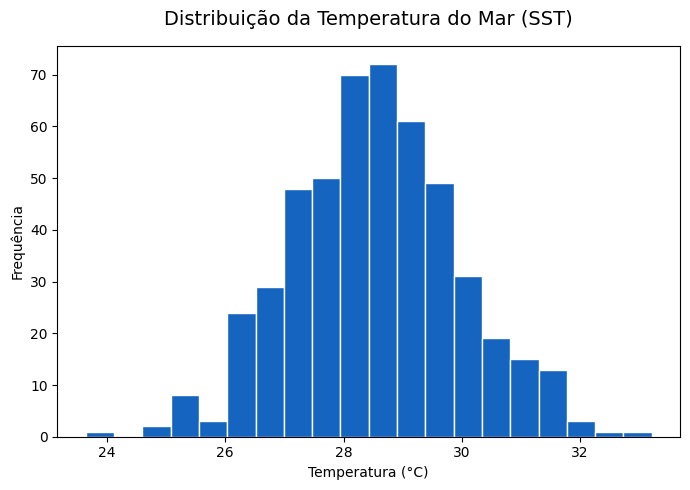

Temperatura média: 28.54°C
Temperatura mínima: 23.64°C
Temperatura máxima: 33.21°C


In [5]:
# Distribuição da temperatura da superfície do mar
plt.figure(figsize=(7,5))
plt.hist(df2['SST (°C)'], bins=20, color='#1565C0', edgecolor='white')
plt.title('Distribuição da Temperatura do Mar (SST)', fontsize=14, pad=15)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

print(f"Temperatura média: {df2['SST (°C)'].mean():.2f}°C")
print(f"Temperatura mínima: {df2['SST (°C)'].min():.2f}°C")
print(f"Temperatura máxima: {df2['SST (°C)'].max():.2f}°C")

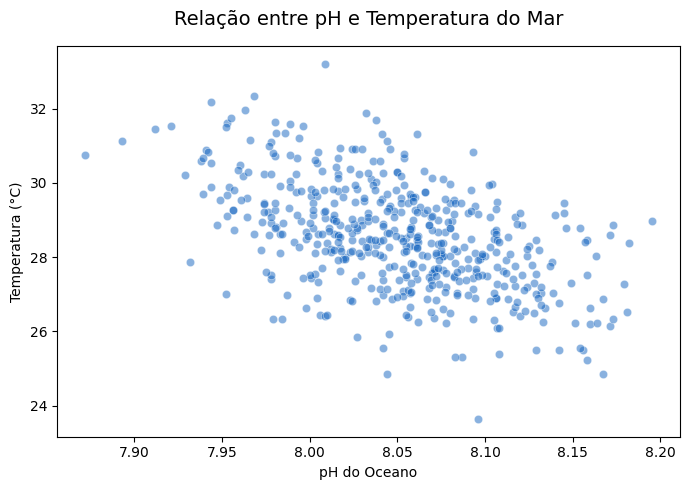

In [6]:
# Relação entre pH e temperatura do mar
# Correlação negativa: quanto menor o pH, maior a temperatura
plt.figure(figsize=(7,5))
plt.scatter(df2['pH Level'], df2['SST (°C)'],
            alpha=0.5, color='#1565C0', edgecolors='white', linewidth=0.5)
plt.title('Relação entre pH e Temperatura do Mar', fontsize=14, pad=15)
plt.xlabel('pH do Oceano')
plt.ylabel('Temperatura (°C)')
plt.tight_layout()
plt.show()

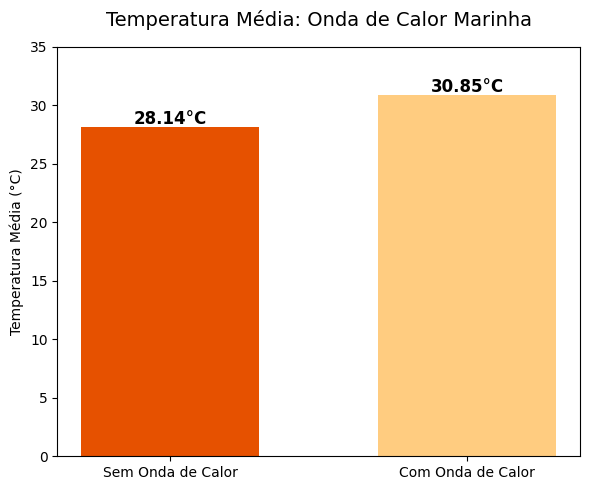

In [7]:
# Temperatura média com e sem onda de calor marinha
plt.figure(figsize=(6,5))
media_heatwave = df2.groupby('Marine Heatwave')['SST (°C)'].mean()
cores = ['#E65100', '#FFCC80']
barras = plt.bar(['Sem Onda de Calor', 'Com Onda de Calor'], media_heatwave.values, color=cores, width=0.6)
plt.title('Temperatura Média: Onda de Calor Marinha', fontsize=14, pad=15)
plt.ylabel('Temperatura Média (°C)')
plt.ylim(0, 35)
for barra in barras:
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.3,
             f'{barra.get_height():.2f}°C',
             ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Selecionando as features e a variável alvo
# Objetivo: prever a temperatura da superfície do mar (SST)
features2 = ['Latitude', 'Longitude', 'pH Level', 'Species Observed', 'Marine Heatwave']
X2 = df2[features2]
y2 = df2['SST (°C)']

# Dividindo em treino (80%) e teste (20%)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print(f"Dados de treino: {X_train2.shape[0]} linhas")
print(f"Dados de teste: {X_test2.shape[0]} linhas")

Dados de treino: 400 linhas
Dados de teste: 100 linhas


In [9]:
# Treinando o modelo Random Forest Regressor
# Regressão prevê um valor numérico contínuo (temperatura em graus)
modelo2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
modelo2.fit(X_train2, y_train2)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [10]:
# Avaliando o desempenho do modelo
y_pred2 = modelo2.predict(X_test2)

mae = mean_absolute_error(y_test2, y_pred2)
rmse = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2 = r2_score(y_test2, y_pred2)

print(f"MAE  (Erro Médio Absoluto):  {mae:.2f}°C")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.2f}°C")
print(f"R²   (Coeficiente de Determinação): {r2:.2f}")

MAE  (Erro Médio Absoluto):  0.69°C
RMSE (Raiz do Erro Quadrático): 0.85°C
R²   (Coeficiente de Determinação): 0.69


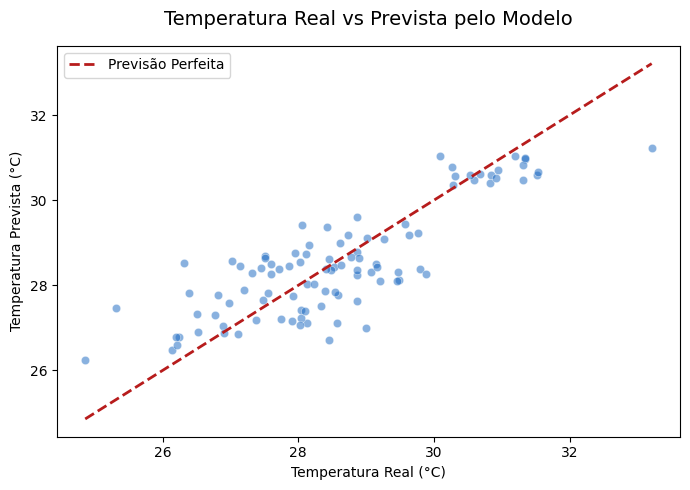

In [11]:
# Gráfico: valores reais vs previstos
# Quanto mais próximos os pontos da linha vermelha, mais preciso o modelo
plt.figure(figsize=(7,5))
plt.scatter(y_test2, y_pred2, alpha=0.5, color='#1565C0', edgecolors='white', linewidth=0.5)
plt.plot([y_test2.min(), y_test2.max()],
         [y_test2.min(), y_test2.max()],
         color='#B71C1C', linewidth=2, linestyle='--', label='Previsão Perfeita')
plt.title('Temperatura Real vs Prevista pelo Modelo', fontsize=14, pad=15)
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Prevista (°C)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\enzoy\AppData\Local\Temp\ipykernel_6820\3314636144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias2, y=features2, palette='Oranges_r')


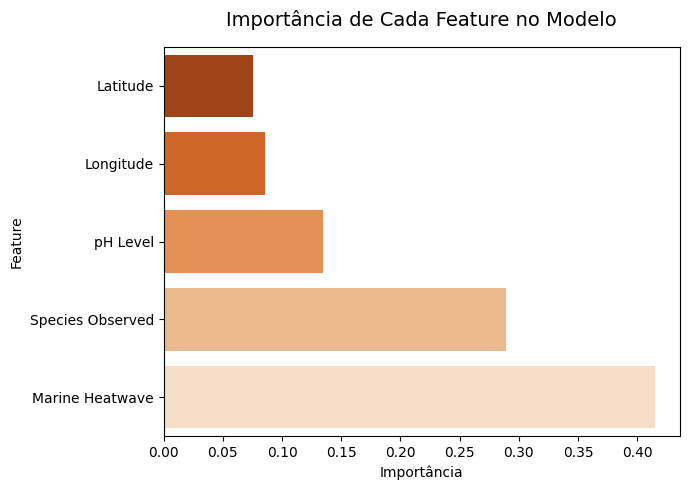

In [12]:
# Importância de cada feature na decisão do modelo
importancias2 = modelo2.feature_importances_

plt.figure(figsize=(7,5))
sns.barplot(x=importancias2, y=features2, palette='Oranges_r')
plt.title('Importância de Cada Feature no Modelo', fontsize=14, pad=15)
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [13]:
# Salvando o modelo treinado para uso na API Flask
joblib.dump(modelo2, 'modelo_regressao.pkl')
print("Modelo salvo com sucesso!")

tamanho = os.path.getsize('modelo_regressao.pkl')
print(f"Arquivo: modelo_regressao.pkl")
print(f"Tamanho: {tamanho / 1024:.1f} KB")

Modelo salvo com sucesso!
Arquivo: modelo_regressao.pkl
Tamanho: 7057.5 KB
